## 1. Data Processing

In [57]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder

from matplotlib import font_manager
from datetime import datetime
import re
import json
import warnings

# Global Settings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [58]:
# Choose rent or sale dataset
isRent = True
# isRent = False

# Choose whether to predict
# isPredict = False
isPredict = True

# Create a timestamped log file
filename_temp = datetime.now().strftime("%Y%m%d_%H%M%S") + "_execution_log.txt"

In [59]:
# Logging Function
def log_message(message, filename=filename_temp, iscurrenttime=False):
    """
    Write logs with or without a timestamp.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    if iscurrenttime:
        log_entry = f"[{timestamp}] {message}\n"
    else:
        log_entry = f"{message}\n"
    
    # Print log to console
    print(log_entry)
    
    # Save log to file
    with open(filename, "a", encoding="utf-8") as f:
        f.write(log_entry)


# Log the Modeling Type
if isRent:
    log_message("====== 租房建模与预测 ======")
else:
    log_message("====== 卖房建模与预测 ======")


# Font Configuration
# Set Chinese font to avoid garbled labels
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# Record Start Time
current_time_start = datetime.now()

====== 租房建模与预测 ======



In [60]:
# Load data
# When the data file is too large, it cannot be loaded into memory all at once
def load_housing_data_chunked(file_path, chunksize=10000):
    """Read data in chunks"""
    chunks = []
    for chunk in pd.read_csv(file_path, chunksize=chunksize):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

# Load data (including training set + prediction set)
current_time_temp_start = datetime.now()
df = 0

if isRent:
    if isPredict:
        df_pred = load_housing_data_chunked("ruc_Class25Q2_test_rent.csv")
    df = load_housing_data_chunked("ruc_Class25Q2_train_rent.csv")
else:
    if isPredict:
        df_pred = load_housing_data_chunked("ruc_Class25Q2_test_price.csv")
    df = load_housing_data_chunked("ruc_Class25Q2_train_price.csv")

current_time_temp_end = datetime.now()
duration = current_time_temp_end - current_time_temp_start
log_message(f"执行时长: {duration}")
log_message(f"数据维度: {df.shape}")

执行时长: 0:00:03.216165

数据维度: (98899, 46)



### 1.1 Data Inspection

In [61]:
# Preliminary data exploration
print("Data Inspection")

# View basic information
print("数据类型信息：")
print(str(df.dtypes.value_counts()))

print("前五行示例：")
print(df.head())

# Descriptive statistics
print("数值型变量描述性统计（前10列）：")
print(str(df.describe().iloc[:, :10]))

Data Inspection
数据类型信息：
object     35
float64    10
int64       1
Name: count, dtype: int64
前五行示例：
   城市      户型   装修          Price      楼层      面积 朝向        交易时间 付款方式 租赁方式 电梯    车位  用水  用电 燃气    采暖      租期                         配套设施         lon        lat      年份     区县      板块  环线位置  \
0   0  1室1厅1卫  精装修  654646.481811    4/6层  36.42㎡  西  2024-11-28  季付价   整租  无   NaN  民水  民电  有  集中供暖      1年           洗衣机、空调、衣柜、热水器、床、宽带  117.336830  40.930871  2022.0   81.0   145.0  三至四环   
1   0  1室1厅1卫  精装修  665412.057415    4/6层  41.00㎡  南  2024-10-30  季付价   整租  无   NaN  民水  民电  有  集中供暖     NaN        洗衣机、空调、衣柜、电视、热水器、床、宽带  117.450170  40.876186  2022.0    7.0   581.0  二至三环   
2   0  1室1厅1卫  精装修  778222.820548   1/18层  37.36㎡  北  2024-11-12  季付价   整租  有  租用车位  民水  民电  有  集中供暖     NaN        洗衣机、空调、衣柜、电视、热水器、床、宽带  117.516502  40.903514  2022.0   68.0   355.0  三至四环   
3   0  3室1厅2卫  精装修  612084.974699   1/10层  55.42㎡  南  2024-10-14  季付价   整租  有  租用车位  商水  商电  无  集中供暖  5~12个月  洗衣机、空调、衣柜、电视、冰箱、热水器

In [62]:
# Descriptive Statistics
print("\n--- Summary Statistics: Price Dataset ---")
display(df.describe(include='all').T)


--- Summary Statistics: Price Dataset ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
城市,98899.0,NaN,NaN,NaN,4.322157,3.321254,0.0,2.0,3.0,7.0,11.0
户型,98898,208,2室1厅,14437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
装修,25410,1,精装修,25410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,98899.0,NaN,NaN,NaN,582908.981321,621842.402862,17938.070075,241628.183193,394936.892294,724895.447812,15404193.151351
楼层,98894,1051,高楼层/6层,5006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
面积,98899,10981,89.00㎡,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
朝向,98894,91,南,44486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
交易时间,98899,296,2024-06-02,3084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
付款方式,80476,7,季付价,54530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
租赁方式,98899,2,整租,93009,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
# Missing Value Check
print("\n--- Missing Values in Dataset ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Missing Values in Dataset ---
户型             1
装修         73489
楼层             5
朝向             5
付款方式       18423
电梯             4
车位         74135
用水         17740
用电         17324
燃气          4582
采暖         64487
租期         46933
配套设施       30451
区县          4677
板块          5144
环线位置       69663
物业类别       20124
建筑年代       26149
开发商        26984
房屋总数        4631
楼栋总数        4631
物业公司       28753
绿 化 率      24402
容 积 率      24080
物 业 费      22159
建筑结构       20741
物业办公电话     60692
产权描述       20124
供水         21194
供暖         61204
供电         21200
燃气费        25057
供热费        70064
停车位        25479
停车费用       26003
coord_x     4631
coord_y     4631
dtype: int64


In [64]:
# Duplicate Check
dup_df = df.duplicated().sum()
print(f"\nDuplicate rows in price dataset: {dup_df}")


Duplicate rows in price dataset: 0


### 1.2 Data Cleaning
- Handle missing or inconsistent values.  
- Remove duplicated observations.  
- Eliminate variables causing **data leakage** (e.g., community price).  
- Standardize or normalize variables if necessary.

#### 1.2.1 Basic Cleaning

In [65]:
# Drop meaningless columns
df.drop(columns=set(["物业办公电话"]) & set(df.columns), inplace=True)
df_pred.drop(columns=set(["物业办公电话"]) & set(df.columns), inplace=True)

# validation
print(f"dataset shape after cleaning: {df.shape}")

dataset shape after cleaning: (98899, 45)


#### 1.2.2 Extract numeric values

In [66]:
# Numeric Extraction for price_df and rent_df
def extract_numbers(text):
    """
    从文本中提取数字并转换为float
    处理各种格式：'120.5平方米', '3.5元/平米/月', '35%', '1.2-1.96'等。
    如果是一个范围，则取平均值
    """
    if pd.isna(text):
        return np.nan
    
    text_str = str(text).strip()
    
    # Method: Split first, then process, more reliable
    if '-' in text_str and not text_str.startswith('-'):
        # Possibly range data, try to split
        parts = text_str.split('-', 1)  # Split at most once
        numbers = []
        
        for part in parts:
            # Extract numbers from each part
            match = re.search(r'\d+\.?\d*', part)
            if match:
                numbers.append(float(match.group()))
        
        if len(numbers) >= 2:
            # Successfully extracted both ends of the range
            avg_value = np.mean(numbers)
            return avg_value
    
    # If it's not range data or range extraction failed, extract a single number
    match = re.search(r'-?\d+\.?\d*', text_str)
    if match:
        try:
            result = float(match.group())
            return result
        except (ValueError, TypeError):
            return np.nan
            
    return np.nan
 
# --- Define columns to extract numbers for each dataset ---
columns_to_extract = [
    '建筑面积', '套内面积', '房屋总数', '绿 化 率', '物 业 费', 
    '燃气费', '供热费', '停车费用', '楼栋总数'
]

if(isRent):
    columns_to_extract = [
        '楼层', '面积', '房屋总数', '楼栋总数', '绿 化 率', 
        '容 积 率', '物 业 费', '燃气费', '供热费', '停车费用']


# --- Apply numeric extraction for price_df ---
print("\nProcessing df...")
for col in columns_to_extract:
    if col in df.columns:
        df[col] = df[col].apply(extract_numbers)
    else:
        print(f"Column '{col}' not found in df")


# predict
print("\nProcessing df_pred...")
for col in columns_to_extract:
    if col in df_pred.columns:
        df_pred[col] = df_pred[col].apply(extract_numbers)
    else:
        print(f"Column '{col}' not found in df")


Processing df...

Processing df_pred...


In [67]:
# Structured feature transformation

# Layout: Analyze the number of bedrooms, living rooms, kitchens, and bathrooms
def parse_room_info(x):
    if pd.isna(x):
        return pd.Series([None, None, None, None])
    pattern = r'(\d+)室.*?(\d+)厅.*?(\d+)厨.*?(\d+)卫'
    match = re.search(pattern, x)
    if match:
        return pd.Series([int(match.group(1)), int(match.group(2)), int(match.group(3)), int(match.group(4))])
    else:
        # Compatible with formats like "1 room 1 bathroom"
        pattern_alt = r'(\d+)[房室].*?(\d+)卫'
        match_alt = re.search(pattern_alt, x)
        if match_alt:
            return pd.Series([int(match_alt.group(1)), 0, 0, int(match_alt.group(2))])
        else:
            return pd.Series([None, None, None, None])

if(isRent):
    df[['室数', '厅数', '厨数', '卫数']] = df['户型'].apply(parse_room_info)
    df_pred[['室数', '厅数', '厨数', '卫数']] = df['户型'].apply(parse_room_info)
    
else:
    df[['室数', '厅数', '厨数', '卫数']] = df['房屋户型'].apply(parse_room_info)
    df_pred[['室数', '厅数', '厨数', '卫数']] = df['房屋户型'].apply(parse_room_info)
    

In [68]:
# Parse floor information from text field
def parse_floor(x):
    """
    Parse the 'floor' field into two numerical variables:
    1. floor_type  (categorical → numeric code)
    2. total_floors (numeric)
    
    Handles cases like:
      - '高楼层 (共6层)'
      - '中层 (共12层)'
      - '地下室 (共2层)'
      - '顶层'
      - '底层'
    """
    # Return empty values if input is NaN
    if pd.isna(x):
        return pd.Series([None, None])

    text = str(x).strip()

    # Pattern: Match full expressions such as “高楼层 (共6层)” or “地下室 (共2层)”
    pattern = r'(地下室|地下|底|低|中|高|顶)[层楼室]*.*?共\s*(\d+)\s*层'
    match = re.search(pattern, text)
    if match:
        floor_map = {
            '地下': 0,
            '地下室': 0,
            '底': 1,
            '低': 2,
            '中': 3,
            '高': 4,
            '顶': 5
        }
        floor_type = floor_map.get(match.group(1), None)
        total_floors = int(match.group(2))
        return pd.Series([floor_type, total_floors])

    # Pattern: Match simpler expressions such as “高楼层”, “中层”, “地下室”
    match_simple = re.search(r'(地下室|地下|底|低|中|高|顶)[层楼室]*', text)
    if match_simple:
        floor_map = {
            '地下': 0,
            '地下室': 0,
            '底': 1,
            '低': 2,
            '中': 3,
            '高': 4,
            '顶': 5
        }
        floor_type = floor_map.get(match_simple.group(1), None)
        return pd.Series([floor_type, None])

    # Pattern: If nothing matches, return None
    return pd.Series([None, None])


if(isRent):
    df[['楼层类型', '总楼层']] = df['楼层'].apply(parse_floor)
    
    # Check the result
    df[['楼层', '楼层类型', '总楼层']].head()

    df_pred[['楼层类型', '总楼层']] = df_pred['楼层'].apply(parse_floor)
        
else:
    df[['楼层类型', '总楼层']] = df['所在楼层'].apply(parse_floor)
    
    # Check the result
    df[['所在楼层', '楼层类型', '总楼层']].head()

    df_pred[['楼层类型', '总楼层']] = df_pred['所在楼层'].apply(parse_floor)

In [69]:
# Parse '梯户比例' into numeric ratio (Supports mixed writing of Chinese, English, and numbers.)
def parse_ratio(x):
    """
    Parse '梯户比例' into numeric ratio (e.g. '一梯三户' -> 0.333).
    Supports:
      - Chinese numerals: '一梯三户', '两梯十一户'
      - Arabic numerals: '2梯5户'
    Returns: float or None
    """
    if pd.isna(x):
        return None

    text = str(x).strip()

    # Chinese numerals mapping (0–99)
    cn_num_map = {
        "零": 0, "〇": 0,
        "一": 1, "二": 2, "两": 2, "三": 3, "四": 4, "五": 5,
        "六": 6, "七": 7, "八": 8, "九": 9,
        "十": 10,
    }

    def cn2num(cn_text):
        """Convert Chinese numerals (0–99) to int"""
        if not cn_text:
            return None

        # Case: only '十' (means 10)
        if cn_text == "十":
            return 10

        # Case: starts with '十' (e.g. '十三' = 13)
        if cn_text.startswith("十"):
            tail = cn_text[1:]
            return 10 + cn_num_map.get(tail, 0) if tail else 10

        # Case: ends with '十' (e.g. '三十' = 30)
        if cn_text.endswith("十"):
            head = cn_text[0]
            return cn_num_map.get(head, 0) * 10

        # Case: '三十五' = 35
        if "十" in cn_text:
            head, tail = cn_text.split("十", 1)
            head_val = cn_num_map.get(head, 0)
            tail_val = cn_num_map.get(tail, 0)
            return head_val * 10 + tail_val

        # Pure digit (e.g. '三' = 3)
        return cn_num_map.get(cn_text, None)

    # Match Arabic numbers (e.g. "2梯5户")
    match = re.search(r'(\d+)\s*梯\s*(\d+)\s*户', text)
    if match:
        t, h = int(match.group(1)), int(match.group(2))
        return round(t / h, 3) if h != 0 else None

    # Match Chinese numerals (e.g. "一梯三户", "两梯十一户")
    match_cn = re.search(r'([一二三四五六七八九十两〇零]+)\s*梯\s*([一二三四五六七八九十两〇零]+)\s*户', text)
    if match_cn:
        t_cn = cn2num(match_cn.group(1))
        h_cn = cn2num(match_cn.group(2))
        if t_cn is not None and h_cn not in (None, 0):
            return round(t_cn / h_cn, 3)

    return None

if(isRent == False):
    # Apply to DataFrame
    df['梯户比'] = df['梯户比例'].apply(parse_ratio)  
    df_pred['梯户比'] = df_pred['梯户比例'].apply(parse_ratio)  
    
    # Check result
    print(df[['梯户比例', '梯户比']].head())


In [70]:
# Convert ring location to numeric code
def parse_ring(x):
    """
    Convert '环线位置' textual info to numeric values.
    """
    if pd.isna(x):
        return None

    text = str(x).strip()

    # Predefined mapping
    mapping = {
        '内环内': 0.5,
        '二环内': 1.0,
        '一至二环': 1.5,
        '二至三环': 2.5,
        '三至四环': 3.5,
        '四至五环': 4.5,
        '五至六环': 5.5,
        '六环外': 7.0,
        '内环至中环': 1.5,
        '中环至外环': 2.5,
        '内环至外环': 2.0,
        '外环外': 8.0
    }

    # Direct match
    for k, v in mapping.items():
        if k in text:
            return v

    # Fallback: try to extract numeric Chinese ring number (e.g., "三环" -> 3)
    match = re.search(r'([一二三四五六七八])环', text)
    if match:
        cn_map = {'一': 1, '二': 2, '三': 3, '四': 4, '五': 5, '六': 6}
        return float(cn_map.get(match.group(1), None))

    return None


# Apply transformation
df['环线数值'] = df['环线位置'].apply(parse_ring)
df_pred['环线数值'] = df_pred['环线位置'].apply(parse_ring)

In [71]:
# Building Age: Extract specific years (e.g., take "2005", use median value for "2003-2018")
def parse_build_year(x):
    if pd.isna(x):
        return None
    # Digital year
    match = re.search(r'(\d{4})年', x)
    if match:
        return int(match.group(1))
    # Year range
    match_range = re.search(r'(\d{4})-(\d{4})年', x)
    if match_range:
        return (int(match_range.group(1)) + int(match_range.group(2))) / 2
    return None

df['建筑年代_num'] = df['建筑年代'].apply(parse_build_year)

# Clean up anomalies generated during conversion
df.replace([float('inf'), -float('inf')], None, inplace=True)

df_pred['建筑年代_num'] = df_pred['建筑年代'].apply(parse_build_year)

# Clean up anomalies generated during conversion
df_pred.replace([float('inf'), -float('inf')], None, inplace=True)



In [72]:
# Calculate lease term
def parse_rent_duration(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    # Extract numbers
    nums = [float(x) for x in text.replace('年', '').replace('个月', '').split('~') if x.replace('.', '').isdigit()]
    
    # include “以内”
    if '以内' in text:
        if '年' in text:
            n = nums[0] if nums else float(text.replace('年以内', '').replace('年', '') or 1)
            return n * 12
        elif '月' in text:
            n = nums[0] if nums else float(text.replace('个月以内', '').replace('个月', '') or 6)
            return n
            
    # Take the average of the range
    elif '~' in text and len(nums) == 2:
        if '年' in text:
            return (nums[0] + nums[1]) / 2 * 12
        elif '月' in text:
            return (nums[0] + nums[1]) / 2
    # Single numerical value
    elif '年' in text:
        return nums[0] * 12 if nums else 12
    elif '月' in text:
        return nums[0] if nums else 6
    else:
        return np.nan

# Apply transformation
if(isRent):
    df['租期（月）'] = df['租期'].apply(parse_rent_duration)
    print(df[['租期（月）']].head())
    
    df_pred['租期（月）'] = df_pred['租期'].apply(parse_rent_duration)

   租期（月）
0   12.0
1    NaN
2    NaN
3    8.5
4   12.0


#### 1.2.3 Natural Language Processing

In [73]:
if(isRent == False):
    df[["周边配套","交通出行"]].head()

In [74]:
# Define keyword dictionary (incorporating common sense + sample content)
# ---- Surrounding amenities keywords ----
keywords_facilities = {
    "医院": ["医院", "卫生服务", "诊所", "门诊"],
    "公园": ["公园", "绿地", "景区", "花园", "湖", "广场"],
    "超市": ["超市", "便利店", "物美", "华联", "京客隆", "永辉", "世纪华联", "美廉美", "乐购", "家乐福"],
    "学校": ["学校", "小学", "中学", "大学", "幼儿园", "双语", "教育", "学院"],
    "商场": ["商场", "广场", "购物中心", "百货", "银泰", "万达", "世贸", "蓝岛"],
    "银行": ["银行", "工商", "建设", "农业", "中国银行", "邮政", "招商", "中信", "ATM"],
    "菜市场": ["菜市场", "农贸市场", "早市", "生鲜", "水果", "蔬菜"],
    "餐饮": ["餐饮", "饭店", "餐馆", "酒楼", "食府", "川菜", "湘菜", "美食"],
    "娱乐健身": ["影院", "健身", "会所", "体育", "游泳", "羽毛球", "篮球", "健身房"],
}

# ---- Transportation keywords ----
keywords_transport = {
    "地铁": ["地铁", "轨道交通", "地铁线", "地铁站"],
    "公交": ["公交", "巴士", "车站", "线路", "专线", "公交站"],
    "高速": ["高速", "快速路", "主路", "辅路", "环路", "京承", "京港澳", "机场高速", "京哈"],
    "自驾": ["自驾", "驾车", "开车", "停车", "车位"],
    "班车": ["班车", "接驳车", "通勤车"],
    "交通便利": ["便捷", "方便", "便利", "即达", "发达"]
}

# Define keyword matching function
def keyword_feature(text, keywords):
    """Check if the text contains any of the keywords"""
    if pd.isna(text):
        return 0
    text = str(text)
    return int(any(k in text for k in keywords))

def keyword_count(text, keyword_dict):
    """Count the number of keyword categories matched in the text"""
    if pd.isna(text):
        return 0
    text = str(text)
    count = 0
    for values in keyword_dict.values():
        if any(k in text for k in values):
            count += 1
    return count


def about_life(dfTemp):
    # Extract keyword features for "周边配套"
    for key, values in keywords_facilities.items():
        dfTemp[f"周边配套_{key}"] = dfTemp["周边配套"].apply(lambda x: keyword_feature(x, values))
    
    # Extract keyword features for "交通出行"
    for key, values in keywords_transport.items():
        dfTemp[f"交通出行_{key}"] = dfTemp["交通出行"].apply(lambda x: keyword_feature(x, values))
    
    # compute "配套丰富度" and "交通便利度"
    dfTemp["配套丰富度"] = dfTemp["周边配套"].apply(lambda x: keyword_count(x, keywords_facilities))
    dfTemp["交通便利度"] = dfTemp["交通出行"].apply(lambda x: keyword_count(x, keywords_transport))

    return dfTemp


if(isRent == False):
    df = about_life(df)
    df_pred = about_life(df_pred)
    
    display(df.head(5)[["交通便利度"] + [col for col in df.columns if col.startswith("周边配套_") or col.startswith("交通出行_")][:6]])


In [75]:
if(isRent):
    print(df[['配套设施']].head(10))

                           配套设施
0            洗衣机、空调、衣柜、热水器、床、宽带
1         洗衣机、空调、衣柜、电视、热水器、床、宽带
2         洗衣机、空调、衣柜、电视、热水器、床、宽带
3   洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带
4         洗衣机、空调、衣柜、电视、热水器、床、宽带
5            洗衣机、空调、衣柜、热水器、床、宽带
6            洗衣机、空调、衣柜、热水器、床、宽带
7               洗衣机、空调、热水器、床、宽带
8               洗衣机、空调、热水器、床、宽带
9  洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气


In [76]:
# Define keyword dictionary (based on common household facilities)
keywords_facilities = {
    "洗衣机": ["洗衣机"],
    "空调": ["空调", "中央空调"],
    "衣柜": ["衣柜", "衣橱"],
    "电视": ["电视", "液晶电视"],
    "冰箱": ["冰箱", "双开门冰箱"],
    "热水器": ["热水器"],
    "床": ["床", "单人床", "双人床"],
    "宽带": ["宽带", "网络", "wifi", "WIFI"],
    "暖气": ["暖气", "地暖"],
    "天然气": ["天然气", "燃气", "煤气"],
    "电梯": ["电梯"],
    "阳台": ["阳台"],
    "厨房": ["厨房", "灶台"],
    "卫生间": ["卫生间", "洗手间", "独卫"],
}

# Define function to check if any keyword appears in text
def keyword_feature(text, keywords):
    """Return 1 if any keyword exists in the text, otherwise 0"""
    if pd.isna(text):
        return 0
    return int(any(k in str(text) for k in keywords))

if(isRent):
    # Generate dummy variables (0/1) for each facility
    for key, values in keywords_facilities.items():
        df[f"配套设施_{key}"] = df["配套设施"].apply(lambda x: keyword_feature(x, values))    
    
    df["配套设施丰富度"] = df[[f"配套设施_{k}" for k in keywords_facilities.keys()]].sum(axis=1)

    # Display result
    print(df[[f"配套设施_{k}" for k in keywords_facilities.keys()] + ["配套设施丰富度"]].head(10))

    for key, values in keywords_facilities.items():
        df_pred[f"配套设施_{key}"] = df_pred["配套设施"].apply(lambda x: keyword_feature(x, values))
    
    df_pred["配套设施丰富度"] = df_pred[[f"配套设施_{k}" for k in keywords_facilities.keys()]].sum(axis=1)

   配套设施_洗衣机  配套设施_空调  配套设施_衣柜  配套设施_电视  配套设施_冰箱  配套设施_热水器  配套设施_床  配套设施_宽带  配套设施_暖气  配套设施_天然气  配套设施_电梯  配套设施_阳台  配套设施_厨房  配套设施_卫生间  配套设施丰富度
0         1        1        1        0        0         1       1        1        0         0        0        0        0         0        6
1         1        1        1        1        0         1       1        1        0         0        0        0        0         0        7
2         1        1        1        1        0         1       1        1        0         0        0        0        0         0        7
3         1        1        1        1        1         1       1        1        1         0        0        0        0         0        9
4         1        1        1        1        0         1       1        1        0         0        0        0        0         0        7
5         1        1        1        0        0         1       1        1        0         0        0        0        0         0        6
6         1        1

In [77]:
# Orientation processing
# Remove spaces, standardize separators
def clean_orientation(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = re.sub(r"\s+", "", text)  # Remove extra spaces
    text = text.replace("、", "").replace("/", "").replace("－", "").replace("-", "")
    return text

if(isRent):
    df["朝向"] = df["朝向"].apply(clean_orientation)
else:
    df["房屋朝向"] = df["房屋朝向"].apply(clean_orientation)


directions = ["东", "南", "西", "北"]

for d in directions:
    # If this direction appears in the text, mark it as 1, otherwise 0
    if(isRent):
        df[f"朝向_{d}"] = df["朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
        df_pred[f"朝向_{d}"] = df_pred["朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
    else:
        df[f"朝向_{d}"] = df["房屋朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
        df_pred[f"朝向_{d}"] = df_pred["房屋朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))

In [78]:
# Step: Drop unnecessary columns
# These variables are descriptive but redundant after feature extraction
if(isRent):
    cols_to_drop = ['环线位置',
        '户型', 
        '朝向',
        '交易时间', 
        '客户反馈',
        '建筑年代',
        '租期',
        '配套设施',
        '年份']
else:
    cols_to_drop = ['环线',
        '房屋户型', 
        '所在楼层', 
        '房屋朝向',
        '梯户比例', 
        '环线位置', 
        '交易时间', 
        '上次交易', 
        '建筑年代',
        '客户反馈',
        '交通出行',
        '周边配套',
        '户型介绍',    #Other equivalent information already exists
        '房屋优势',
        '核心卖点',
        '年份',
        '板块_comm',
        '建筑结构_comm']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df_pred.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [79]:
# check remaining data type
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98899 entries, 0 to 98898
Data columns (total 64 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   城市        98899 non-null  int64  
 1   装修        25410 non-null  object 
 2   Price     98899 non-null  float64
 3   楼层        98894 non-null  float64
 4   面积        98899 non-null  float64
 5   付款方式      80476 non-null  object 
 6   租赁方式      98899 non-null  object 
 7   电梯        98895 non-null  object 
 8   车位        24764 non-null  object 
 9   用水        81159 non-null  object 
 10  用电        81575 non-null  object 
 11  燃气        94317 non-null  object 
 12  采暖        34412 non-null  object 
 13  lon       98899 non-null  float64
 14  lat       98899 non-null  float64
 15  区县        94222 non-null  float64
 16  板块        93755 non-null  float64
 17  物业类别      78775 non-null  object 
 18  开发商       71915 non-null  object 
 19  房屋总数      94268 non-null  float64
 20  楼栋总数      94268 non-null  fl

### 1.3 Dataset Splitting
- Split data into training (80%) and testing (20%) sets using a fixed random state. 

In [80]:
# Split df
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=111
)

# Check the result
print(f"df → train: {df_train.shape}, test: {df_test.shape}")

df → train: (79119, 64), test: (19780, 64)


### 1.4 Outlier and missing value

In [108]:

import pandas as pd
import numpy as np

# 统计特征拟合（仅在训练集上）
def fit_missing_outlier_stats(df_train, iqr_factor=1.5, z_thresh=4.0, drop_ratio=0.8):
    """
    在训练集上计算缺失值和异常值的统计量（防止数据泄露）
    —— 仅使用 df_train 的分布特征
    """
    stats = {}
    num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df_train.columns if c not in num_cols]

    # === 1. 删除高缺失比例的列 ===
    drop_cols = [c for c in df_train.columns if df_train[c].isna().mean() > drop_ratio]
    stats["drop_cols"] = drop_cols
    print("=" * 60)
    print(f"高缺失比例列处理：删除 {len(drop_cols)} 个变量：{drop_cols if drop_cols else '无'}")

    # === 2. 数值列统计量 ===
    num_stats = {}
    for col in num_cols:
        s = df_train[col].dropna()
        if s.empty:  # 全缺失列也保留，方便后续填充
            median = 0.0
            q1 = -np.inf
            q3 = np.inf
            mean = 0.0
            std = 1.0
        else:
            median = s.median()
            q1, q3 = s.quantile([0.25, 0.75])
            mean, std = s.mean(), s.std(ddof=0) if s.std(ddof=0) > 0 else 1.0
        iqr = q3 - q1 if s.shape[0] > 0 else 0
        num_stats[col] = {
            "median": median,
            "lower_iqr": q1 - iqr_factor * iqr,
            "upper_iqr": q3 + iqr_factor * iqr,
            "z_lower": mean - z_thresh * std,
            "z_upper": mean + z_thresh * std
        }
    stats["num_stats"] = num_stats

    # === 3. 分类列众数 ===
    cat_stats = {}
    for col in cat_cols:
        mode_val = df_train[col].mode(dropna=True)
        cat_stats[col] = {"mode": mode_val.iloc[0] if not mode_val.empty else 0}  # 全缺失列填 0
    stats["cat_stats"] = cat_stats

    print("已在训练集上计算统计量，用于 transform（防数据泄露）")
    return stats

# ======================================================
# Price 列特殊处理函数（仅训练集）
# ======================================================
def process_price_column(df, price_col="Price", isRent=False, area_col="面积", build_area_col="建筑面积", z_thresh=3.0):
    """
    对价格列进行稳健异常值处理（仅训练集）
    """
    df = df.copy()
    indicators = {}

    # 计算价格面积比
    if isRent:
        price_area = df[price_col] / df[area_col]
    else:
        price_area = df[price_col] / df[build_area_col]

    median = np.nanmedian(price_area)
    mad = np.nanmedian(np.abs(price_area - median)) or 1.0
    robust_z = 0.6745 * (price_area - median) / mad

    # 异常值裁剪
    outlier_mask = np.abs(robust_z) > z_thresh
    if isRent:
        df.loc[outlier_mask, price_col] = median * df.loc[outlier_mask, area_col]
    else:
        df.loc[outlier_mask, price_col] = median * df.loc[outlier_mask, build_area_col]

    # 缺失值填充
    na_mask = df[price_col].isna()
    if isRent:
        df.loc[na_mask, price_col] = median * df.loc[na_mask, area_col]
    else:
        df.loc[na_mask, price_col] = median * df.loc[na_mask, build_area_col]

    indicators[f"{price_col}_was_na"] = na_mask.astype(int)
    return df, indicators

# ======================================================
# 缺失值与异常值处理函数（通用 transform）
# ======================================================
def transform_missing_outlier(df, stats, isRent=False, is_train=False, add_indicators=True):
    """
    基于训练集统计量对 df 进行缺失值与异常值处理
    """
    df = df.copy()
    df = df.drop(columns=[c for c in stats["drop_cols"] if c in df.columns], errors="ignore")
    indicators = {}

    # 数值列处理
    for col, s in stats["num_stats"].items():
        if col not in df.columns:
            continue
        na_mask = df[col].isna()
        df[col] = df[col].fillna(s["median"])
        df[col] = df[col].clip(lower=s["lower_iqr"], upper=s["upper_iqr"])  # IQR截断
        df[col] = df[col].clip(lower=s["z_lower"], upper=s["z_upper"])      # Z-score截断
        if add_indicators:
            indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 分类列处理
    for col, s in stats["cat_stats"].items():
        if col not in df.columns:
            continue
        na_mask = df[col].isna()
        df[col] = df[col].fillna(s["mode"])
        if add_indicators:
            indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 价格列处理（仅训练集）
    if is_train and "Price" in df.columns:
        df, price_indicators = process_price_column(df, isRent=isRent)
        indicators.update(price_indicators)

    # 合并缺失指示器
    if add_indicators and indicators:
        df = pd.concat([df, pd.DataFrame(indicators)], axis=1)

    return df

# ======================================================
# 主流程调用
# ======================================================
# 假设 isRent 是你事先定义的布尔值

# Step 0: 在训练集上拟合统计量
df_stats = fit_missing_outlier_stats(df_train)
# 训练集 
df_clean_train = transform_missing_outlier(df_train, df_stats, isRent=isRent, is_train=True)

# 测试集
df_clean_test = transform_missing_outlier(df_test, df_stats, isRent=isRent, is_train=False)

# 预测集
df_clean_pred = transform_missing_outlier(df_pred, df_stats, isRent=isRent, is_train=False)


# 汇总删除信息
print("=" * 60)
print(f"共删除 {len(df_stats['drop_cols'])} 个变量。")
if df_stats["drop_cols"]:
    print("删除变量列表：", df_stats["drop_cols"])
else:
    print("无变量被删除。")
print("=" * 60)


共删除 7 个变量。
删除变量列表： ['供热费', '室数', '厅数', '厨数', '卫数', '环线数值', '租期（月）']


## 2. Feature Engineering

### 2.1 Categorical variables

In [84]:
# 类别变量处理
import pandas as pd

# 假设 df 已经加载

# 定义字段
df_cols = [
    "建筑结构", '装修情况', '配备电梯', '别墅类型',
    "交易权属", "房屋用途", "房屋年限", "产权所属", "物业类别",
    "开发商", "物业公司", "产权描述", "供水", "供暖", "供电"
]

if(isRent):
    df_cols = [
        "装修", "付款方式", "租赁方式", "电梯", "车位",
        "用水", "用电", "燃气", "采暖", 
        "物业类别", "开发商", "物业公司",
        "建筑结构", "产权描述", "供水", "供暖", "供电"]

def check_unique(dfTemp):
    Existing = [col for col in df_cols if col in dfTemp.columns]
    # 计算唯一值数量
    unique = {col: dfTemp[col].nunique(dropna=True) for col in Existing}
    
    # 转为DataFrame便于展示
    unique_summary = pd.DataFrame({
        "df_unique_values": pd.Series(unique)}).fillna("-").astype(str)
    
    # 显示结果
    print(unique_summary)
    return unique_summary
    
# --- train
# 检查列是否存在（防止缺失）
print("检查df_train中object型变量的unique value个数：")
check_unique(df_train)

检查df_train中object型变量的unique value个数：
     df_unique_values
装修                  1
付款方式                7
租赁方式                2
电梯                  2
车位                  2
用水                  2
用电                  2
燃气                  2
采暖                  2
物业类别              232
开发商              2056
物业公司             1909
建筑结构               14
产权描述              163
供水                  3
供暖                  6
供电                  3


,df_unique_values
装修,1
付款方式,7
租赁方式,2
电梯,2
车位,2
用水,2
用电,2
燃气,2
采暖,2
物业类别,232


In [85]:

# ======================
# 删除独特值超过50或仅一个的变量
# ======================

def drop_irrelevant_categoricals(dfTemp, threshold=50):
    drop_cols = []
    for col in dfTemp.select_dtypes(include=['object']).columns:
        unique_vals = dfTemp[col].dropna().unique()
        n_unique = len(unique_vals)
        if n_unique > threshold or n_unique == 1:
            drop_cols.append(col)
    return dfTemp.drop(columns=drop_cols, errors='ignore'), drop_cols

# 在训练集上确定要删除的列
df_train, dropped_cols = drop_irrelevant_categoricals(df_train)

# 同步删除两边的列
df_train = df_train.drop(columns=dropped_cols, errors='ignore')
df_test = df_test.drop(columns=dropped_cols, errors='ignore')

print("Dropped (df_train):", dropped_cols)

# ------------------------------
df_pred = df_pred.drop(columns=dropped_cols, errors='ignore')



Dropped (df_train): ['装修', '物业类别', '开发商', '物业公司', '产权描述']


In [86]:
# 处理映射交易权属 & 房屋用途
if(isRent == False):
    df_train[['交易权属', '房屋用途']].head(20)

In [87]:
# 映射交易权属 & 房屋用途
ownership_map = {
    '商品房':'商品房','已购公房':'公房','限价商品房':'经济适用房',
    '一类经济适用房':'经济适用房','央产房':'公房','私产':'其他',
    '二类经济适用房':'经济适用房','动迁安置房':'安置房','房改房':'公房',
    '经济适用房':'经济适用房','拆迁还建房':'安置房','集资房':'公房',
    '定向安置房':'安置房','售后公房':'公房','回迁房':'安置房'
}

usage_map = {
    '住宅':'住宅', '普通住宅':'住宅','公寓':'公寓','老公寓':'公寓','公寓（住宅）':'公寓',
    '住宅式公寓':'公寓','公寓/住宅':'住宅','花园洋房':'别墅','别墅':'别墅',
    '商业办公类':'商业','商住两用':'商业住宅','底商':'商业','商业':'商业',
    '写字楼':'商业','商务公寓':'商业','酒店式公寓':'公寓',
    '新式里弄':'其他','四合院':'住宅','商务型公寓':'公寓'
}

def map_price_categoricals(dfTemp):
    if '交易权属' in dfTemp.columns:
        dfTemp['交易权属'] = dfTemp['交易权属'].map(ownership_map).fillna('其他')
    if '房屋用途' in dfTemp.columns:
        dfTemp['房屋用途'] = dfTemp['房屋用途'].map(usage_map).fillna('其他')
    return dfTemp

df_train = map_price_categoricals(df_train)
df_test = map_price_categoricals(df_test)
df_pred = map_price_categoricals(df_pred)


In [88]:
# 建筑结构编码（适用于 price & rent）
def encode_building_type(text):
    if pd.isna(text):
        text = ""
    text = str(text)
    return pd.Series({
        "塔楼": int("塔" in text),
        "板楼": int("板" in text),
        "平房": int("平" in text)
    })

def process_building_structure(dfTemp):
    if '建筑结构' in dfTemp.columns:
        encoded = dfTemp['建筑结构'].apply(encode_building_type)
        dfTemp = pd.concat([dfTemp.drop(columns=['建筑结构']), encoded], axis=1)
    return dfTemp

df_train = process_building_structure(df_train)
df_test = process_building_structure(df_test)
df_pred = process_building_structure(df_pred)

In [89]:
# 二值变量转0/1，其余one-hot编码
# 类别编码器类（训练集 fit，测试集/预测集 transform）
class SafeCategoricalEncoder:
    def __init__(self):
        self.binary_maps = {}  # 二值变量映射
        self.ohe = None        # OneHotEncoder 对象
        self.cat_cols = []     # 所有类别列（非数值）
    
    def fit(self, df: pd.DataFrame):
        df_temp = df.copy()
        self.cat_cols = df_temp.select_dtypes(include=['object']).columns.tolist()
        
        # 二值变量编码
        binary_cols = []
        for col in self.cat_cols:
            unique_vals = df_temp[col].dropna().unique()
            if len(unique_vals) == 2:
                self.binary_maps[col] = {unique_vals[0]: 0, unique_vals[1]: 1}
                binary_cols.append(col)
        
        # 多类别 One-Hot
        multi_cols = [c for c in self.cat_cols if c not in binary_cols]
        if multi_cols:
            self.ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            self.ohe.fit(df_temp[multi_cols])
        
        return self
    
    def transform(self, df: pd.DataFrame):
        df_temp = df.copy()
        
        # 二值变量编码
        for col, mapping in self.binary_maps.items():
            if col in df_temp.columns:
               
                try:
                   # 先将 NaN 转为 0，再进行映射
                    df_temp[col] = df_temp[col].map(mapping).fillna(0)
                    # 确保类型是整数
                    df_temp[col] = df_temp[str].astype(int)
                    df_temp[col] = df_temp[col].map(mapping).fillna(0).astype(int)
                except (ValueError, TypeError):
                    # 打印出可能有问题的列
                    print(df_temp[col].unique())
                    
                    # 检查 NaN 的位置
                    print(df_temp[df_temp[col].isna()])
               
        
        # 多类别 One-Hot
        multi_cols = [c for c in self.cat_cols if c not in self.binary_maps]
        if multi_cols and self.ohe is not None:
            # 处理缺失值，填充NaN（如果有的话）
            df_temp[multi_cols] = df_temp[multi_cols].fillna('missing')  # 或根据需求填充
        
            # 确保数据为字符串类型
            df_temp[multi_cols] = df_temp[multi_cols].astype(str)
        
            # 进行One-Hot编码
            ohe_array = self.ohe.transform(df_temp[multi_cols])
            
            # 获取编码后的列名
            ohe_cols = self.ohe.get_feature_names_out(multi_cols)
            
            # 创建编码后的DataFrame
            df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_temp.index)
            
            # 合并原数据和编码后的数据
            df_temp = pd.concat([df_temp.drop(columns=multi_cols), df_ohe], axis=1)

        return df_temp

# 训练集 fit
encoder = SafeCategoricalEncoder()
encoder.fit(df_train)

# 编码训练集
df_train_enc = encoder.transform(df_train)
df_train = df_train_enc

# 编码测试集
df_test_enc = encoder.transform(df_test)
df_test = df_test_enc

# 编码预测集
df_pred_enc = encoder.transform(df_pred)
df_pred = df_pred_enc

In [90]:
# 检查结果
print("df_train shape:", df_train.shape)

# 显示所有列
pd.set_option('display.max_columns', None)

# 显示所有行
pd.set_option('display.max_rows', None)
# 查看 df_train 列名和数据类型
print("===== df 列名与类型 =====")
print(df_train.dtypes)

df_train shape: (79119, 80)
===== df 列名与类型 =====
城市                                       int64
Price                                  float64
楼层                                     float64
面积                                     float64
租赁方式                                     int64
电梯                                       int64
车位                                       int64
用水                                       int64
用电                                       int64
燃气                                       int64
采暖                                       int64
lon                                    float64
lat                                    float64
区县                                     float64
板块                                     float64
房屋总数                                   float64
楼栋总数                                   float64
绿 化 率                                  float64
容 积 率                                  float64
物 业 费                                  float64
燃气费        

### 2.2 Non-linear features

In [91]:
def create_features(dfTemp):
    """
    Create meaningful features for both buying (price) and renting (rent) properties based on provided datasets.
    The features are designed with specific relevance to the real estate market.
    """

    # Iterate over both price and rent dataframes for general feature creation

    # 1. 房龄特征：计算房屋的年龄（2025年作为当前年）
    if "建筑年代_num" in dfTemp.columns:
        dfTemp["房龄"] = 2025 - dfTemp["建筑年代_num"]
    
    # 2. 厅卧比：厅数与室数的比例，反映房屋的布局
    if "厅数" in dfTemp.columns and "室数" in dfTemp.columns:
        dfTemp["厅卧比"] = dfTemp["厅数"] / (dfTemp["室数"] + 1e-5)
    
    # 3. 厨卫比：厨房与卫生间的比例，通常反映房屋的功能分区
    if "厨数" in dfTemp.columns and "卫数" in dfTemp.columns:
        dfTemp["厨卫比"] = dfTemp["厨数"] / (dfTemp["卫数"] + 1e-5)
    
    # 4. 朝向得分：根据朝向设定权重，计算房屋朝向的综合得分
    if "朝向_南" in dfTemp.columns:
        dfTemp["朝向得分"] = 2 * dfTemp["朝向_南"]
    if "朝向_东" in dfTemp.columns:
        dfTemp["朝向得分"] += dfTemp["朝向_东"]
    if "朝向_西" in dfTemp.columns:
        dfTemp["朝向得分"] += dfTemp["朝向_西"]

    # 5. 对数变换：对高度偏斜的变量进行对数变换（如价格、面积等）
    if "建筑面积" in dfTemp.columns:
        dfTemp["log_建筑面积"] = np.log1p(dfTemp["建筑面积"])
    if "套内面积" in dfTemp.columns:
        dfTemp["log_套内面积"] = np.log1p(dfTemp["套内面积"])
    if "面积" in dfTemp.columns:
        dfTemp["log_面积"] = np.log1p(dfTemp["面积"])

    # 特有的房产买卖（price）特征
    if(isRent == False):         
        # 7. 梯户比：梯户比有时会影响购房者的选择，进行对数变换
        if "梯户比" in dfTemp.columns:
            dfTemp["梯户比_log"] = np.log1p(dfTemp["梯户比"])
        
        # 8. 生活便利指数：结合配套丰富度与交通便利度，计算生活便利指数
        if "配套丰富度" in dfTemp.columns and "交通便利度" in dfTemp.columns:
            dfTemp["生活便利指数"] = dfTemp["配套丰富度"] * dfTemp["交通便利度"]
        
        # 9. 房龄的平方：房龄对价格有较大影响，进行平方处理
        if "房龄" in dfTemp.columns:
            dfTemp["房龄平方"] = dfTemp["房龄"] ** 2
        
        # 10. 楼层与房龄交互：楼层与房龄的组合特征，体现低楼层和旧房可能对价格的影响
        if "楼层类型" in dfTemp.columns and "房龄" in dfTemp.columns:
            dfTemp["楼层房龄交互"] = dfTemp["楼层类型"] * dfTemp["房龄"]
    
        # 11. 上下楼便捷程度：结合梯户比和楼层类型，评估楼层的便捷性
        if "梯户比" in dfTemp.columns and "楼层类型" in dfTemp.columns:
            # 设置楼层权重
            # 假设：低楼层较方便，中楼层较为均衡，高楼层不便捷
            dfTemp["上下楼便捷程度"] = dfTemp["梯户比"] * dfTemp["楼层类型"]
            dfTemp["上下楼便捷程度"] = dfTemp["上下楼便捷程度"].clip(lower=0)  # 确保没有负值

    return dfTemp


In [92]:
df_clean_train = create_features(df_clean_train)
df_clean_test = create_features(df_clean_test)

# 查看处理后的数据
print(df_clean_train.head())

# ---------------
df_clean_pred = create_features(df_clean_pred)


       城市   装修         Price    楼层      面积 付款方式 租赁方式 电梯    车位  用水  用电 燃气    采暖         lon        lat     区县      板块                  物业类别             开发商    房屋总数  楼栋总数            物业公司  绿 化 率  \
66850   7  精装修  3.132104e+05  29.0   40.16  月付价   整租  有  租用车位  民水  民电  有  集中供暖  115.284052  23.723170  131.0  1177.0  普通住宅/写字楼/商业/底商/商业办公类      正中置业集团有限公司   950.0   3.0   深圳市鸿基物业管理有限公司  28.00   
71707   7  精装修  9.174774e+05  32.0   88.00  月付价   整租  有  租用车位  民水  民电  有  集中供暖  115.105014  23.540701   99.0   818.0                  普通住宅  深圳市华盛房地产开发有限公司   448.0   2.0      越众物业管理有限公司  20.25   
61913   5  精装修  1.001237e+06  35.0  132.00  季付价   整租  有  租用车位  民水  民电  有  集中供暖  114.582123  23.163062  125.0   636.0                  普通住宅     珠海市华发股份有限公司   896.0   6.0  珠海华发物业管理服务有限公司  35.00   
35080   3  精装修  3.209228e+05   7.0   92.00  季付价   整租  无  租用车位  民水  民电  有  集中供暖  122.123757  32.304795   64.0   921.0                  普通住宅            无开发商  2652.0  58.5   三河市宝嘉物业服务有限公司  35.00   
3691    0  精装修  7.232864e

### 2.3 Missing value & Outlier again

In [93]:
# 参数（可按需调整）
IQR_FACTOR = 1.5    # IQR 的倍数（常用 1.5）
Z_thresh = 3.0      # z-score 裁剪阈值（常用 3）
DROP_COL_MISSING_RATIO = 0.4  # 若列缺失比例超过此值则丢弃（可设为 None 以禁用）
ADD_MISSING_INDICATORS = True  # 是否为每个原始列增加 isna 指示器

# Cell 2 - inspection utilities
def missing_summary(dfTemp, top_n=20):
    total = dfTemp.shape[0]
    miss = dfTemp.isna().sum().sort_values(ascending=False)
    miss_pct = (miss / total).round(4)
    summary = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    return summary[summary['missing_count']>0]

def basic_numeric_summary(dfTemp, cols=None):
    if cols is None:
        cols = dfTemp.select_dtypes(include=[np.number]).columns.tolist()
    return dfTemp[cols].describe().T[['count','mean','std','min','25%','50%','75%','max']]


# 请在执行前确保 df_train已加载
print("df missing (top):")
display(missing_summary(df_train).head(30))

df missing (top):


,missing_count,missing_pct
供热费,56031,0.7082
环线数值,55745,0.7046
室数,51258,0.6479
卫数,51258,0.6479
厨数,51258,0.6479
厅数,51258,0.6479
租期（月）,37617,0.4754
停车费用,22751,0.2876
建筑年代_num,20911,0.2643
停车位,20352,0.2572


In [94]:
# Cell 3 - compute and store stats on a DataFrame
from collections import defaultdict

def fit_missing_outlier_stats(dfTemp, iqr_factor=IQR_FACTOR):
    """
    仅在 df_train 上计算并返回所需的统计量字典（用于后续 transform）
    """
    stats = {}
    n = dfTemp.shape[0]
    num_cols = dfTemp.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in dfTemp.columns if c not in num_cols]

    # optional: drop columns with too many missing (based on config)
    drop_cols = []
    if DROP_COL_MISSING_RATIO is not None:
        for c in dfTemp.columns:
            miss_ratio = dfTemp[c].isna().mean()
            if miss_ratio > DROP_COL_MISSING_RATIO:
                drop_cols.append(c)

    stats['drop_cols'] = drop_cols

    # numeric statistics
    num_stats = {}
    for col in num_cols:
        col_ser = dfTemp[col].dropna()
        if col_ser.shape[0] == 0:
            median = 0.0
            q1 = q3 = iqr = 0.0
            mean = 0.0
            std = 1.0
        else:
            median = col_ser.median()
            q1 = col_ser.quantile(0.25)
            q3 = col_ser.quantile(0.75)
            iqr = q3 - q1
            mean = col_ser.mean()
            std = col_ser.std(ddof=0) if col_ser.std(ddof=0) > 0 else 1.0

        lower_iqr = q1 - iqr_factor * iqr
        upper_iqr = q3 + iqr_factor * iqr
        # z bounds using mean/std
        z_lower = mean - Z_thresh * std
        z_upper = mean + Z_thresh * std

        num_stats[col] = {
            'median': median,
            'q1': q1, 'q3': q3, 'iqr': iqr,
            'lower_iqr': lower_iqr, 'upper_iqr': upper_iqr,
            'mean': mean, 'std': std,
            'z_lower': z_lower, 'z_upper': z_upper
        }

    stats['num_stats'] = num_stats

    # categorical statistics (mode)
    cat_stats = {}
    for col in cat_cols:
        # get mode if possible
        try:
            mode_val = dfTemp[col].mode(dropna=True)
            mode_val = mode_val.iloc[0] if not mode_val.empty else np.nan
        except Exception:
            mode_val = np.nan
        cat_stats[col] = {'mode': mode_val}

    stats['cat_stats'] = cat_stats
    return stats

# Fit stats for price and rent separately
df_stats = fit_missing_outlier_stats(df_train)

# 简要查看
print("df: dropped cols (by missing ratio):", df_stats['drop_cols'])


df: dropped cols (by missing ratio): ['供热费', '室数', '厅数', '厨数', '卫数', '环线数值', '租期（月）']


In [95]:
# Cell 4 - transform function applying train stats to a dataframe (train or test)
# 用训练集统计量对 df 执行填补与裁剪（transform 函数）
# 改进后的函数：一次性添加缺失指示器列
def transform_missing_outlier(dfTemp, stats, add_indicators=ADD_MISSING_INDICATORS):
    """
    Apply imputation and outlier handling based on stats (computed from train).
    Returns transformed_df, and a small report dict.
    """
    dfTemp = dfTemp.copy()
    report = {'filled_missing_cols': [], 'applied_winsor_cols': [], 'applied_zcap_cols': []}

    # Drop globally dropped columns (if present)
    for c in stats.get('drop_cols', []):
        if c in dfTemp.columns:
            dfTemp = dfTemp.drop(columns=[c])

    # 创建一个用于存储缺失指示器列的字典
    missing_indicators = {}

    # numeric columns according to stats
    for col, s in stats['num_stats'].items():
        if col not in dfTemp.columns:
            continue

        # 1) missing -> median
        median_val = s['median']
        na_mask = dfTemp[col].isna()
        if na_mask.any():
            dfTemp[col] = dfTemp[col].fillna(median_val)
            report['filled_missing_cols'].append(col)

        # 2) IQR winsorize (clip)
        lower_iqr, upper_iqr = s['lower_iqr'], s['upper_iqr']
        dfTemp[col] = dfTemp[col].clip(lower=lower_iqr, upper=upper_iqr)
        report['applied_winsor_cols'].append(col)

        # 3) z-score cap (based on train mean/std)
        z_low, z_high = s['z_lower'], s['z_upper']
        dfTemp[col] = dfTemp[col].clip(z_low, z_high)
        report['applied_zcap_cols'].append(col)

        # 4) Optional: Add missing indicator column
        if add_indicators:
            missing_indicators[f"{col}_was_na"] = na_mask.astype(int)

    # categorical columns
    for col, s in stats['cat_stats'].items():
        #if col not in df.columns:
        if col not in dfTemp.columns:
            continue
        mode_val = s['mode']
        #na_mask = df[col].isna()
        na_mask = dfTemp[col].isna()
        if na_mask.any():
            dfTemp[col] = dfTemp[col].fillna(mode_val)
            report.setdefault('filled_cat_cols', []).append(col)

        # Optional: Add missing indicator column
        if add_indicators:
            missing_indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 使用 pd.concat 合并所有缺失指示器列
    if add_indicators:
        indicator_df = pd.DataFrame(missing_indicators)
        dfTemp = pd.concat([dfTemp, indicator_df], axis=1)

    return dfTemp, report


# 应用到 df_train
df_clean_train, report_df_train = transform_missing_outlier(df_train, df_stats, add_indicators=True)
print("df_train report:", report_df_train.keys())

# 应用到 df_test
df_clean_test, report_df_test = transform_missing_outlier(df_test, df_stats, add_indicators=True)
print("df_test report:", report_df_test.keys())

# ---------------------
# 应用到 df_pred
df_clean_pred, report_df_pred = transform_missing_outlier(df_pred, df_stats, add_indicators=True)
print("df_pred report:", report_df_test.keys())

df_train report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])
df_test report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])
df_pred report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])


In [96]:
# Cell 5 - validation checks
# 检查与验证（填补与裁剪后）

def check_after_proc(original_train, processed_train):
    print("=== TRAIN ===")
    print("Original missing total:", original_train.isna().sum().sum())
    print("Processed missing total:", processed_train.isna().sum().sum())
    print("\n=== TEST ===")

    # show numeric summaries for a few sample columns (first 10 numeric columns)
    sample_num_cols = processed_train.select_dtypes(include=[np.number]).columns.tolist()[:10]
    print("\nSample numeric summary (processed train):")
    display(processed_train[sample_num_cols].describe().T)

# run checks for df_train
check_after_proc(df_train, df_clean_train)


=== TRAIN ===
Original missing total: 517571
Processed missing total: 0

=== TEST ===

Sample numeric summary (processed train):


,count,mean,std,min,25%,50%,75%,max
城市,79119.0,4.315980,3.321763,0.000000,2.000000,3.000000,7.000000,1.100000e+01
Price,79119.0,527180.716982,370546.844198,17938.070075,241546.260919,395011.470853,725475.860943,1.451370e+06
楼层,79119.0,18.975509,11.185276,0.000000,8.000000,18.000000,29.000000,5.267170e+01
面积,79119.0,79.017319,37.095775,6.050000,50.285000,78.980000,99.800000,1.740725e+02
租赁方式,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
电梯,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
车位,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
用水,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
用电,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
燃气,79119.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


### 2.4 Feature selection

In [97]:
# 定义要移除的列列表
columns_to_remove = [
    '装修情况',
    '配备电梯', 
    '交易权属',
    '房屋用途',
    '产权所属',
    '供水',
    '供电'
]

# 移除这些列
df_clean_train = df_clean_train.drop(columns=columns_to_remove, errors='ignore')
df_clean_test = df_clean_test.drop(columns=columns_to_remove, errors='ignore')

# -----------------------
df_clean_pred = df_clean_pred.drop(columns=columns_to_remove, errors='ignore')

# 方法2：使用filter函数
def remove_col_byfilter(dfTemp):
    was_na_columns = list(filter(lambda x: x.endswith('_was_na'), dfTemp.columns))
    
    print(f"找到 {len(was_na_columns)} 个以 _was_na 结尾的列:")
    print(was_na_columns)
    
    # 移除这些列
    dfTemp = dfTemp.drop(columns=was_na_columns)
    print(f"移除后数据框形状: {dfTemp.shape}")
    
    return dfTemp

df_clean_train = remove_col_byfilter(df_clean_train)
df_clean_test = remove_col_byfilter(df_clean_test)

# -----------------
df_clean_pred = remove_col_byfilter(df_clean_pred)



找到 73 个以 _was_na 结尾的列:
['城市_was_na', 'Price_was_na', '楼层_was_na', '面积_was_na', '租赁方式_was_na', '电梯_was_na', '车位_was_na', '用水_was_na', '用电_was_na', '燃气_was_na', '采暖_was_na', 'lon_was_na', 'lat_was_na', '区县_was_na', '板块_was_na', '房屋总数_was_na', '楼栋总数_was_na', '绿 化 率_was_na', '容 积 率_was_na', '物 业 费_was_na', '燃气费_was_na', '停车位_was_na', '停车费用_was_na', 'coord_x_was_na', 'coord_y_was_na', '建筑年代_num_was_na', '配套设施_洗衣机_was_na', '配套设施_空调_was_na', '配套设施_衣柜_was_na', '配套设施_电视_was_na', '配套设施_冰箱_was_na', '配套设施_热水器_was_na', '配套设施_床_was_na', '配套设施_宽带_was_na', '配套设施_暖气_was_na', '配套设施_天然气_was_na', '配套设施_电梯_was_na', '配套设施_阳台_was_na', '配套设施_厨房_was_na', '配套设施_卫生间_was_na', '配套设施丰富度_was_na', '朝向_东_was_na', '朝向_南_was_na', '朝向_西_was_na', '朝向_北_was_na', '塔楼_was_na', '板楼_was_na', '平房_was_na', '付款方式_https://image1.ljcdn.com/rent-_was_na', '付款方式_https://img.ljcdn.com/usercent_was_na', '付款方式_半年付价_was_na', '付款方式_双月付价_was_na', '付款方式_季付价_was_na', '付款方式_年付价_was_na', '付款方式_月付价_was_na', '付款方式_nan_was_na', '供水_商水_was_na', '供

In [98]:
df_final_train = df_clean_train.copy()
df_final_test = df_clean_test.copy()
# ----------------------
df_final_pred = df_clean_pred.copy()


In [99]:
len(df_final_pred)

9773

In [100]:
# 设置中文字体（根据操作系统不同，可能需要设置为其他路径）
font_path = 'C:/Windows/Fonts/simhei.ttf'  # Windows下的黑体字体路径
font_prop = font_manager.FontProperties(fname=font_path)

# 定义不需要的特征列
exclude_columns = [
    "周边配套_医院", "周边配套_公园", "周边配套_超市", "周边配套_学校", "周边配套_商场",
    "周边配套_银行", "周边配套_菜市场", "周边配套_餐饮", "周边配套_娱乐健身",
    "交通出行_地铁", "交通出行_公交", "交通出行_高速", "交通出行_自驾", "交通出行_班车",
    "交通出行_交通便利", "朝向_东", "朝向_南", "朝向_西", "朝向_北", "塔楼", "板楼",
    "平房", "装修情况_其他", "装修情况_毛坯", "装修情况_简装", "装修情况_精装", "别墅类型_双拼",
    "别墅类型_叠拼", "别墅类型_独栋", "别墅类型_联排", "交易权属_公房", "交易权属_其他",
    "交易权属_商品房", "交易权属_安置房", "交易权属_经济适用房", "房屋用途_住宅", "房屋用途_公寓",
    "房屋用途_其他", "房屋用途_别墅", "房屋用途_商业", "房屋用途_商业住宅", "房屋年限_未满两年",
    "房屋年限_满两年", "房屋年限_满五年", "供水_商水", "供水_商水/民水", "供水_民水",
    "供暖_无供暖", "供暖_自采暖", "供暖_自采暖/无供暖", "供暖_集中供暖", "供暖_集中供暖/自采暖",
    "供暖_集中供暖/自采暖/无供暖", "供电_商电", "供电_商电/民电", "供电_民电"
]

if(isRent):
    exclude_columns = [
        "配套设施_洗衣机", "配套设施_空调", "配套设施_衣柜", "配套设施_电视", "配套设施_冰箱",
        "配套设施_热水器", "配套设施_床", "配套设施_宽带", "配套设施_暖气", "配套设施_天然气",
        "配套设施_电梯", "配套设施_阳台", "配套设施_厨房", "配套设施_卫生间", "朝向_东", "朝向_南",
        "朝向_西", "朝向_北", "塔楼", "板楼", "平房", "付款方式_半年付价", "付款方式_双月付价",
        "付款方式_季付价", "付款方式_年付价", "付款方式_月付价", "供水_商水", "供水_商水/民水",
        "供水_民水", "供暖_无供暖", "供暖_自采暖", "供暖_自采暖/无供暖", "供暖_集中供暖",
        "供暖_集中供暖/自采暖", "供暖_集中供暖/自采暖/无供暖", "供电_商电", "供电_商电/民电", "供电_民电"
    ]


# 移除不需要的列
df_final_train = df_final_train.drop(columns=exclude_columns, errors='ignore')
df_final_test = df_final_test.drop(columns=exclude_columns, errors='ignore')

# ---------------------
df_final_pred = df_final_pred.drop(columns=exclude_columns, errors='ignore')


#### 2.4.1 Correlation Analysis

In [101]:

# Step 1: 处理 NaN 和 inf
def handle_missing_and_infinite_train(dfTrain, dfTest, dfPred):
    # 计算训练集的中位数
    median_train = dfTrain.median()

    # 用训练集的中位数填充训练集的缺失值
    dfTrain = dfTrain.fillna(median_train)

    # 用训练集的中位数填充测试集和预测集的缺失值
    dfTest = dfTest.fillna(median_train)
    dfPred = dfPred.fillna(median_train)

    # 将无穷大值替换为NaN，然后使用中位数填充
    dfTrain.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfTest.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfPred.replace([np.inf, -np.inf], np.nan, inplace=True)

    dfTrain = dfTrain.fillna(median_train)
    dfTest = dfTest.fillna(median_train)
    dfPred = dfPred.fillna(median_train)

    return dfTrain, dfTest, dfPred

# 调用函数并填充缺失值
df_final_train, df_final_test, df_final_pred = handle_missing_and_infinite_train(df_final_train, df_final_test, df_final_pred)
        

Removed features with high or low correlation to target: ['板块', '楼层', '绿 化 率', '容 积 率', '楼栋总数']


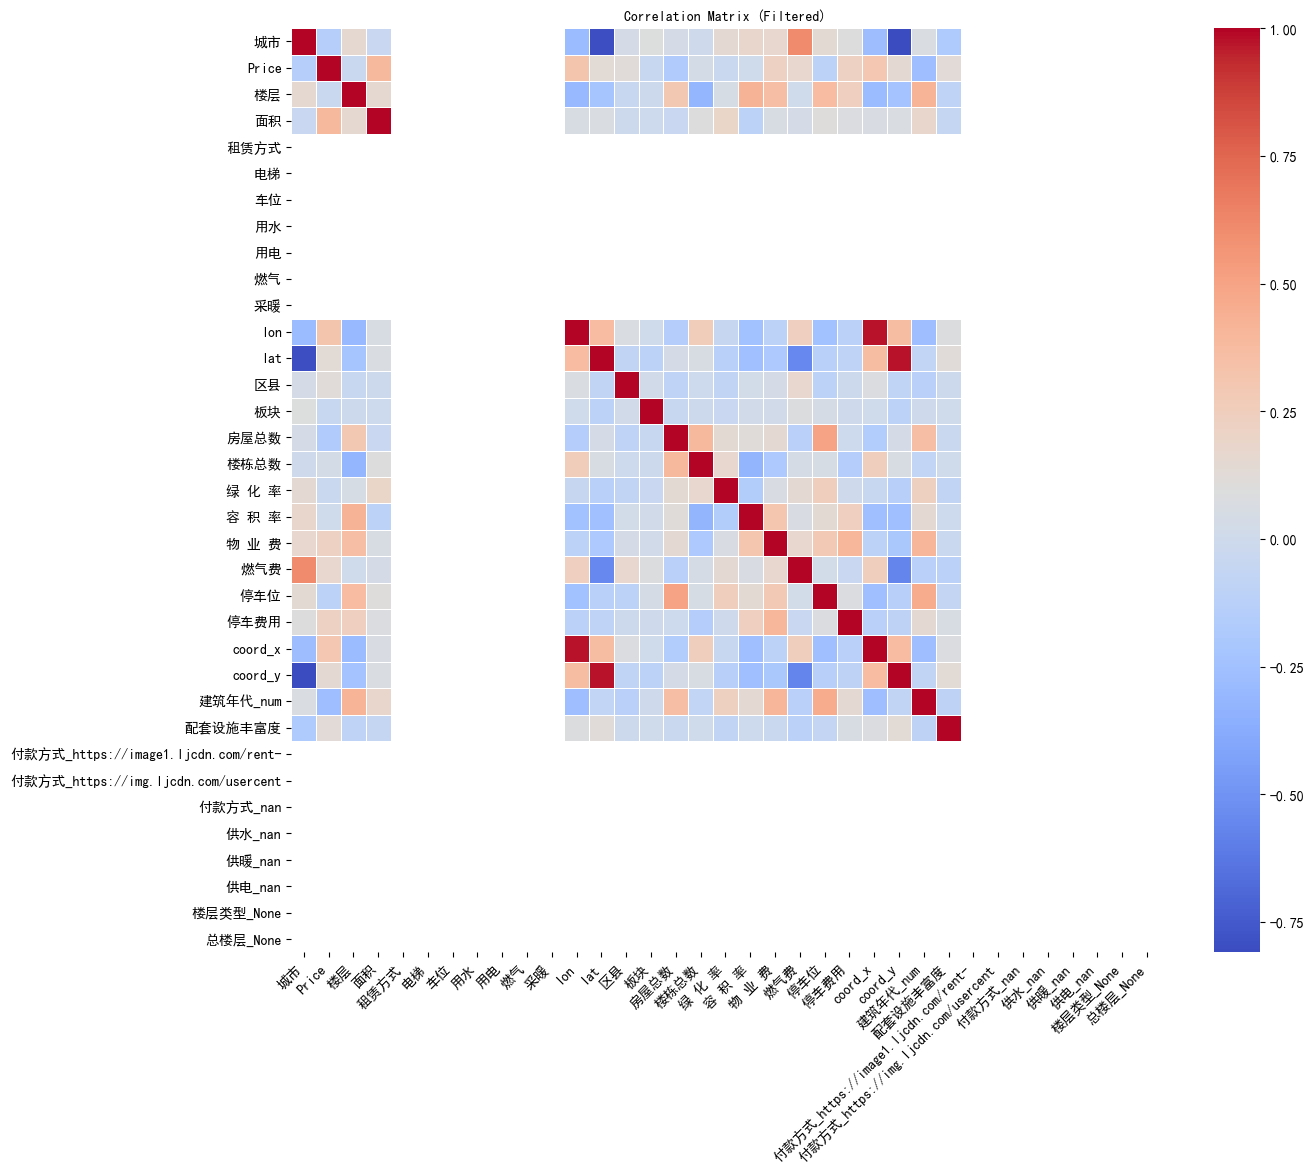

In [102]:
# Step 2: Correlation Analysis (Price)
def correlation_analysis(dfTrain, dfTest, target_column, high_corr_threshold=0.9, low_corr_threshold=0.1):
    # 仅在训练集上计算相关性
    dfTrain = dfTrain.select_dtypes(include=[np.number])
    corr_matrix_train = dfTrain.corr()
    
    # 找到与目标变量高度相关和低相关的特征
    high_corr_features = corr_matrix_train[target_column][abs(corr_matrix_train[target_column]) > high_corr_threshold].index.tolist()
    low_corr_features = corr_matrix_train[target_column][abs(corr_matrix_train[target_column]) < low_corr_threshold].index.tolist()

    # 不删除目标变量本身
    features_to_remove = [f for f in set(high_corr_features + low_corr_features) if f != target_column]
    print(f"Removed features with high or low correlation to target: {features_to_remove}")
    
    # 在训练集上删除这些特征
    dfTrain = dfTrain.drop(columns=features_to_remove, errors='ignore')
    
    # 在测试集和预测集上移除相同的特征
    dfTest = dfTest.drop(columns=features_to_remove, errors='ignore')
    
    return dfTrain, dfTest, corr_matrix_train

# 执行训练集的相关性分析
df_final_train, df_final_test, corr_matrix_train = correlation_analysis(df_final_train, df_final_test, target_column='Price')

# 展示最终的相关性热图
plt.figure(figsize=(14, 12))  # 调整图像大小
sns.heatmap(corr_matrix_train, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)  # 不展示相关系数
plt.title("Correlation Matrix (Filtered)", fontsize=20, fontproperties=font_prop)
plt.xticks(rotation=45, ha='right', fontsize=12, fontproperties=font_prop)
plt.yticks(rotation=0, fontsize=12, fontproperties=font_prop)
plt.show()


#### 2.4.2 VIF

In [103]:
# Step 3: VIF (方差膨胀系数)
# Step 3: 计算VIF并移除高VIF特征，仅在训练集上计算
def calculate_vif(dfTrain, dfTest, target_column='Price'):
    """
    计算VIF并移除高多重共线性特征，完全保护目标变量
    """
    print(f"=== VIF计算开始，保护目标列: {target_column} ===")
    
    # 检查目标列是否存在
    if target_column not in dfTrain.columns:
        print(f"Error: 目标列 '{target_column}' 不存在于数据框中!")
        return dfTrain, dfTest, []

    # 分离训练集的特征和目标变量
    target_series_train = dfTrain[target_column].copy()
    features_df_train = dfTrain.drop(columns=[target_column])
    
    # 确保训练集数据是数值型
    features_df_train = features_df_train.select_dtypes(include=[np.number])
    
    # 处理 NaN 和 Inf 数据
    features_df_train = features_df_train.replace([np.inf, -np.inf], np.nan)
    features_df_train = features_df_train.fillna(features_df_train.median())
    
    # 计算VIF值
    vif_data_train = pd.DataFrame()
    vif_data_train["features"] = features_df_train.columns
    vif_data_train["VIF"] = [variance_inflation_factor(features_df_train.values, i) for i in range(features_df_train.shape[1])]
    
    # 移除VIF值超过5的特征
    high_vif_features = vif_data_train[vif_data_train["VIF"] > 5]["features"].tolist()
    if high_vif_features:
        features_df_train = features_df_train.drop(columns=high_vif_features)
    
    # 重新组合训练数据
    dfTrain = pd.concat([features_df_train, target_series_train], axis=1)
    
    # 在验证集上删除相同的高VIF特征
    dfTest = dfTest.drop(columns=high_vif_features, errors='ignore')
    
    return dfTrain, dfTest, high_vif_features


# Step 3: VIF (完全保护Price列)

print("Before VIF calculation:")
print("数据框形状:", df_final_train.shape)
print("列名:", df_final_train.columns.tolist())
print("Price列数据类型:", df_final_train['Price'].dtype if 'Price' in df_final_train.columns else 'Not Found')

# 执行VIF计算
df_final_train, df_final_test, high_vif_features = calculate_vif(df_final_train, df_final_test, target_column='Price')

# 对预测集应用相同的特征删除
df_final_pred = df_final_pred.drop(columns=high_vif_features, errors='ignore')

print("After VIF calculation:")
print("数据框形状:", df_final_train.shape)
print("Price列是否保留:", 'Price' in df_final_train.columns)

if 'Price' in df_final_train.columns:
    print("Price列样本值:")
    print(df_final_train['Price'].head())
else:
    print("ERROR: Price列丢失了!")
    # 紧急恢复
    print("尝试恢复原始数据...")
    # 这里需要你重新加载或恢复原始数据


Before VIF calculation:
数据框形状: (79119, 30)
列名: ['城市', 'Price', '面积', '租赁方式', '电梯', '车位', '用水', '用电', '燃气', '采暖', 'lon', 'lat', '区县', '房屋总数', '物 业 费', '燃气费', '停车位', '停车费用', 'coord_x', 'coord_y', '建筑年代_num', '配套设施丰富度', '付款方式_https://image1.ljcdn.com/rent-', '付款方式_https://img.ljcdn.com/usercent', '付款方式_nan', '供水_nan', '供暖_nan', '供电_nan', '楼层类型_None', '总楼层_None']
Price列数据类型: float64
=== VIF计算开始，保护目标列: Price ===
After VIF calculation:
数据框形状: (79119, 19)
Price列是否保留: True
Price列样本值:
66850    3.132104e+05
71707    9.174774e+05
61913    1.001237e+06
35080    3.209228e+05
3691     7.232864e+05
Name: Price, dtype: float64


In [104]:
# debug
print("After featuring:")
msg = df_final_train.info()
print(f"{msg}")
print(f"数据集形状: {df_final_train.shape}")
# 显示所有列名
print("列名:", df_final_train.columns.tolist())

After featuring:
<class 'pandas.core.frame.DataFrame'>
Index: 79119 entries, 66850 to 77652
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   租赁方式                                 79119 non-null  int64  
 1   电梯                                   79119 non-null  int64  
 2   车位                                   79119 non-null  int64  
 3   用水                                   79119 non-null  int64  
 4   用电                                   79119 non-null  int64  
 5   燃气                                   79119 non-null  int64  
 6   采暖                                   79119 non-null  int64  
 7   房屋总数                                 79119 non-null  float64
 8   停车位                                  79119 non-null  float64
 9   配套设施丰富度                              79119 non-null  int64  
 10  付款方式_https://image1.ljcdn.com/rent-  79119 non-null  float64
 11  付款方式_https:/

In [105]:

# 仅在训练集上选取特征
target_column = 'Price'
train_features = df_final_train.drop(columns=[target_column])

# 训练集特征
X_train = train_features
y_train = df_final_train[target_column]

# 测试集特征：根据训练集选择的特征
X_test = df_final_test[train_features.columns]
y_test = df_final_test[target_column]

# 预测集特征：根据训练集选择的特征
X_pred = df_final_pred[train_features.columns]

## 3. Modeling

### 3.1 Basic linear model

In [110]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from datetime import datetime

def model_training_evaluation(models, X_train, y_train, X_test, y_test, X_pred, df_pred, isRent=False):
    """
    训练、评估并生成结果文件，仅输出MAE指标表格
    """
    start_time = datetime.now()
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    scaler = StandardScaler()

    print("4.0 特征标准化...")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_pred_scaled = scaler.transform(X_pred)

    metrics_list = []  # 存储所有模型的结果

    for mode_name, model in models.items():
        print("\n" + "=" * 50)
        print(f"步骤4: {mode_name} 模型训练与评估")
        print("=" * 50)

        # ===== 1️⃣ 交叉验证 MAE =====
        cv_mae_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
        cv_mae = cv_mae_scores.mean()

        # ===== 2️⃣ 模型拟合 =====
        model.fit(X_train_scaled, y_train)

        # ===== 3️⃣ 预测 =====
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        y_pred_pred = model.predict(X_pred_scaled)

        # ===== 4️⃣ 计算 MAE =====
        in_sample_mae = mean_absolute_error(y_train, y_train_pred)
        out_sample_mae = mean_absolute_error(y_test, y_test_pred)

        # ===== 5️⃣ 记录指标 =====
        metrics_list.append({
            'Metrics': mode_name,
            'In sample': in_sample_mae,
            'Out of sample': out_sample_mae,
            'Cross-validation': cv_mae
        })

        # ===== 6️⃣ 保存预测结果 =====
        # Save predictions if not rent data
        if not isRent:
            results_df = pd.DataFrame({'ID': df_pred['ID'], 'Price': y_pred_pred})
            output_file = f"{mode_name}_predict.csv"
            results_df.to_csv(output_file, index=False, mode='w', header=True)
            print(f"\n✅ 预测结果（{mode_name}）已保存到: {output_file}")
        else:
            results_df = pd.DataFrame({'ID': df_pred['ID'], 'Price': y_pred_pred})
            output_file = f"{mode_name}_predict.csv"
            results_df.to_csv(output_file, mode='a', header=False, index=False)
            print(f"\n✅ 预测结果（{mode_name}）已追加到: {output_file}")

    # ===== 汇总输出表格 =====
    metrics_df = pd.DataFrame(metrics_list)
    print("\n模型 MAE 结果汇总（越小越好）:")
    print(metrics_df.round(4))

    duration = datetime.now() - start_time
    print(f"\n总执行时长: {duration}")

    # Track the execution time
    current_time_end = datetime.now()
    duration = current_time_end - current_time_start
    print(f"总的执行时长: {duration}")
    return metrics_df
        
# Initialize models
lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)

models = {'OLS': lr, 'Lasso': lasso, 'Ridge': ridge, 'ElasticNet': elasticnet}

# Call the function with the models

metrics_df = model_training_evaluation(
    models,
    X_train, y_train,
    X_test, y_test,   # ✅ 测试集标签
    X_pred, df_pred,  # ✅ 预测集数据及其ID
    isRent)

4.0 特征标准化...

步骤4: OLS 模型训练与评估

✅ 预测结果（OLS）已追加到: OLS_predict.csv

步骤4: Lasso 模型训练与评估

✅ 预测结果（Lasso）已追加到: Lasso_predict.csv

步骤4: Ridge 模型训练与评估

✅ 预测结果（Ridge）已追加到: Ridge_predict.csv

步骤4: ElasticNet 模型训练与评估

✅ 预测结果（ElasticNet）已追加到: ElasticNet_predict.csv

模型 MAE 结果汇总（越小越好）:
      Metrics    In sample  Out of sample  Cross-validation
0         OLS  287171.9101    286829.2095       287193.0228
1       Lasso  287171.9241    286829.2229       287193.0363
2       Ridge  287171.9151    286829.2130       287193.0289
3  ElasticNet  287385.7986    286988.7916       287406.7138

总执行时长: 0:00:02.345939
总的执行时长: 0:35:14.303797


### 3.2 Model tuning

#### 3.2.1 Polynomial features

In [112]:
# ======================== 生成多项式特征（非线性项） ========================
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_pred_scaled = scaler.transform(X_pred)

# 生成多项式特征
degree = 2  # 设置多项式阶数，可调节以提升模型非线性拟合能力
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
X_pred_poly = poly.transform(X_pred_scaled)

# ======================== 定义模型 ========================
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

models = {
    'OLS': LinearRegression(),
    'Lasso': Lasso(alpha=0.1),
    'Ridge': Ridge(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

# ======================== 模型训练与评估 ========================

metrics_df = model_training_evaluation(
    models,
    X_train_poly, y_train,
    X_test_poly, y_test,   # ✅ 测试集标签
    X_pred_poly, df_pred,  # ✅ 预测集数据及其ID
    isRent)

4.0 特征标准化...

步骤4: OLS 模型训练与评估

✅ 预测结果（OLS）已追加到: OLS_predict.csv

步骤4: Lasso 模型训练与评估

✅ 预测结果（Lasso）已追加到: Lasso_predict.csv

步骤4: Ridge 模型训练与评估

✅ 预测结果（Ridge）已追加到: Ridge_predict.csv

步骤4: ElasticNet 模型训练与评估

✅ 预测结果（ElasticNet）已追加到: ElasticNet_predict.csv

模型 MAE 结果汇总（越小越好）:
      Metrics    In sample  Out of sample  Cross-validation
0         OLS  284867.9943    284838.3400       284906.8177
1       Lasso  284868.0237    284838.3642       284906.8472
2       Ridge  284868.0106    284838.3556       284906.8372
3  ElasticNet  285447.9109    285377.2242       285483.2063

总执行时长: 0:00:21.879123
总的执行时长: 0:36:48.297978
